## F-Praktikum: Spectroscopy of supernova SN 1987A v3.0
## Data Inspection

In [15]:
import numpy as np

from os.path import join as jp
import matplotlib.pyplot as plt

from astropy.io import fits

## 1. Load Data Files

The SN 1987A spectroscopy data have been exported from the native MIDAS format to the portable FITS (Flexible Image Transport System) format, which can be read using `astropy`.

In [16]:
data_path = '../fits'

with fits.open(jp(data_path, 'sn.mt')) as hdul:
    # the fits interface returns a HDU (Header Data Unit) list
    hdul.info()

Filename: ../fits/sn.mt
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     102   (1201, 110)   float32   


## 2. Extract Header and Data

Access the first (and only) HDU in the file, which contains the header metadata and the spectral data array.

In [17]:
with fits.open(jp(data_path, 'sn.mt')) as hdul:
    header, data = hdul[0].header, hdul[0].data

## 3. Examine the FITS Header

Inspect the header to understand the data structure and calibration information:

In [18]:
header

SIMPLE  =                    T / Standard FITS format: NOST 100-2.0             
BITPIX  =                  -32 / No. of bits per pixel                          
NAXIS   =                    2 / No. of axes in image                           
NAXIS1  =                 1201 / No. of pixels                                  
NAXIS2  =                  110 / No. of pixels                                  
EXTEND  =                    T / FITS extension may be present                  
COMMENT NOST 100-2.0: Hanisch,R. et al. 2001, Astron. & Astrophys. 376, 559     
                                                                                
CRPIX1  =                   1. / Reference pixel                                
CRVAL1  =                3000. / Coordinate at reference pixel                  
CDELT1  =                   5. / Coord. incr. per pixel (original value)        
CTYPE1  = '                '   / Units of coordinate                            
CRPIX2  =                   

**FITS Format Overview:**
- `NAXIS = 2`: Data is 2-dimensional
- `NAXIS1 = 1201`: Wavelength axis (number of Ångström points)
- `NAXIS2 = 110`: Time axis (observation days)

Verify the data shape matches these dimensions:

In [19]:
data.shape

(110, 1201)

**Important:** FITS axis ordering is transposed relative to NumPy array conventions. `NAXIS1` (wavelength) becomes the second dimension in the array.

## 4. Construct the Wavelength Axis

Build an array of wavelength values using FITS header parameters:
- `CRVAL1`: wavelength of the first pixel (Ångström)
- `CDELT1`: wavelength step between consecutive pixels (Ångström)
- `NAXIS1`: number of wavelength points

Create an array of `NAXIS1` evenly-spaced values starting from `CRVAL1` with step `CDELT1`:

In [20]:
n = header['NAXIS1']
start = header['CRVAL1']
delta = header['CDELT1']
# using `np.arange` to create an array of evenly spaced values
wl = np.arange(start, start + n * delta, delta)
# check if the array has the correct size
print(wl.shape)

(1201,)


## 5. Plot Observed Spectra

Visualize the SN 1987A spectrum evolution across different observation days. The spectra show increasing absorption features and changing continuum as the supernova ejects its envelope:


To identify absorption and emission features in the spectra, refer to reference tables of common emission lines. For example:
- [Table of Emission Lines (NMSU)](http://astronomy.nmsu.edu/drewski/tableofemissionlines.html) — comprehensive wavelength reference for optical transitions

Text(0, 0.5, 'flux [10$^{-12}$ J m$^{-2}$ s$^{-1}$ nm$^{-1}$]')

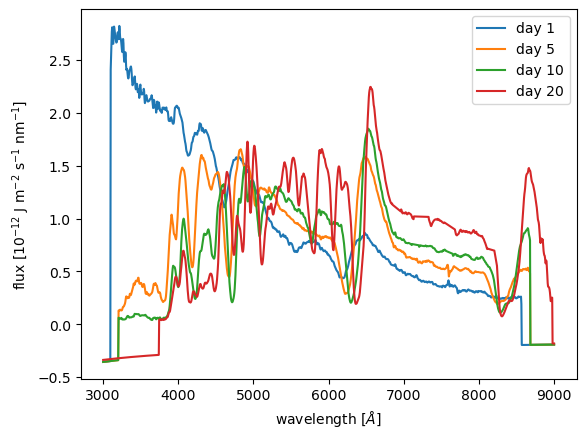

In [21]:
days = [1, 5, 10, 20]

fig, ax = plt.subplots()

for day in days:
    index = day - 1 # arrays count from zero but days from one
    ax.plot(wl, data[index], label=f'day {day}')

ax.legend()
ax.set_xlabel(r"wavelength [$\AA$]")
ax.set_ylabel(r"flux [10$^{-12}$ J m$^{-2}$ s$^{-1}$ nm$^{-1}$]")

# fig.savefig('spectra.png')